In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import seaborn as sns
import numpy as np

from konlpy.tag import Okt
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# matplotlib의 한글문제를 해결
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# font_name
rc('font', family=font_name)

In [ ]:
# 제목 + 본문 합치기 / 카테고리별 개수 확인
df = pd.read_csv('dataset/naver_news_category.csv')
df = df[['Title', 'Article', 'PressCompany', 'Category']]
df['Document'] = df['Title'] + ' ' + df['Article']
df = df.drop(['Title', 'Article'], axis=1)
df['Category'].value_counts(sort=False)

Category
정치       1400
경제       1400
사회       1400
생활/문화    1400
IT/과학    1400
Name: count, dtype: int64

In [3]:
# 겹치는 본문 확인
dup = df.duplicated(['Document']).value_counts()
dup

False    6972
True       28
Name: count, dtype: int64

In [4]:
# 중복 본문 제거 후 카테고리별 개수 확인
df.drop_duplicates('Document', inplace=True, ignore_index=True)
df['Category'].value_counts(sort=False)

Category
정치       1392
경제       1395
사회       1390
생활/문화    1399
IT/과학    1396
Name: count, dtype: int64

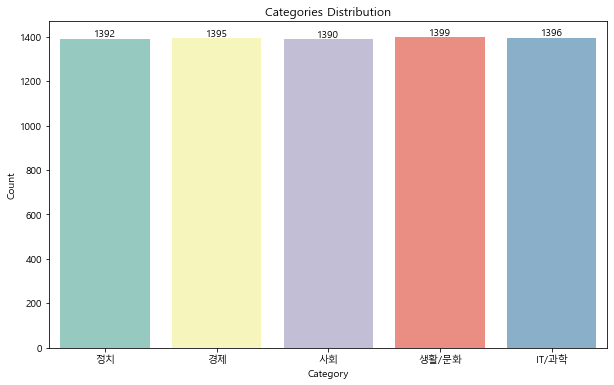

In [5]:
# 'Categories' 열의 고유한 값과 각 값의 빈도 계산
category_distribution = df['Category'].value_counts(sort=False)

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=category_distribution.index, y=category_distribution.values, palette="Set3")
ax.bar_label(ax.containers[0], label_type='edge', fontsize=10) # 각 막대 위에 개수 표시
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

# 큰 차이는 없기에 언더 샘플링이나 오버 샘플링 없이 진행

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6972 entries, 0 to 6971
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PressCompany  6972 non-null   object
 1   Category      6972 non-null   object
 2   Document      6972 non-null   object
dtypes: object(3)
memory usage: 163.5+ KB


In [7]:
df.head(3)

,PressCompany,Category,Document
0,뉴스1,정치,"日, 11년째 '독도는 일본땅' 주장…""역사·국제법상 日 고유 영토""(상보) 韓 정..."
1,파이낸셜뉴스,정치,"""김정은이 요새 대놓고 순항미사일만 쏴대는 까닭은"" 1주일 사이 3차례나 순항미사일..."
2,오마이뉴스,정치,듣도 보도 못한 TV조선의 '핼로윈 특별법' 이태원 참사 특별법을 '핼로윈 특별법'...


In [ ]:
# https://www.ranks.nl/stopwords/korean
# 텍스트 파일로 저장한 한국어 불용어 사전을 읽어오기
with open('dataset/Korean Stopwords.txt', 'r', encoding='utf-8') as file:
    stopwords = [line.strip() for line in file]

# 읽어온 불용어 리스트 확인
print(stopwords[:50])

['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라', '의해', '을', '를', '에', '의', '가', '으로', '로', '에게', '뿐이다', '의거하여', '근거하여', '입각하여', '기준으로', '예하면', '예를 들면', '예를 들자면', '저', '소인', '소생', '저희', '지말고', '하지마', '하지마라', '다른', '물론', '또한', '그리고', '비길수 없다', '해서는 안된다', '뿐만 아니라', '만이 아니다', '만은 아니다', '막론하고', '관계없이', '그치지 않다', '그러나', '그런데', '하지만', '든간에']


In [ ]:
tokenizer = Okt()  # 형태소 분석기 초기화

# 텍스트 데이터를 전처리 (명사, 형용사, 동사만 추출 & 불용어 제거)
def preprocess_text(text):
    tokens = tokenizer.pos(text)  # 텍스트를 형태소로 분리
    filtered_pos_tokens = [word for word, pos in tokens if pos in ['Noun', 'Adjective', 'Verb'] and word not in stopwords] # 명사, 형용사, 동사만 추출 & 불용어 제거
    return " ".join(filtered_pos_tokens)  # 추출된 단어들을 문자열로 변환하여 반환

In [ ]:
# preprocess_text 함수 적용된 데이터 (시간이 오래걸려 한번 수행 후 csv파일로 저장해둠.)
df = pd.read_csv('dataset/Pre-processing_news.csv')
df

,PressCompany,Category,Document
0,뉴스1,정치,독도 일본 땅 주장 역사 국제 법 고유 영토 상보 정부 강력히 항의 한일 관계 도움...
1,파이낸셜뉴스,정치,김정은 요새 순항미사일 쏴 대는 까닭 주일 사이 차례 순항미사일 도발 반길주 유엔 ...
2,오마이뉴스,정치,듣도 보도 못 조선 핼로윈 특별법 이태원 참사 특별법 핼로윈 특별법 이라 칭해 정식...
3,연합뉴스,정치,이재명 오늘 신년 회견 총선 각오 밝히고 민주당 지지 호소 정권 비판 하며 대안 제...
4,국제신문,정치,속보 대통령 이태원 특별법 거부권 행사 취임 후 윤석열 대통령 이태원 특별법 이태원...
...,...,...,...
6967,블로터,IT/과학,흑자 달성 디스플레이 과제 재무 건전 디스플레이 파주 공장 전경 사진 디스플레이 예...
6968,머니투데이,IT/과학,하반신 마비 쥐 신약 맞고 걸었다 영상 다리 근육 뻣뻣해지다가 마비 되는 질환 생명...
6969,블로터,IT/과학,경영 불안 요기 이정환 대표 사임 설 마케팅 확대 제동 불가피 이정환 요기 대표 사...
6970,디지털타임스,IT/과학,삼바 영업 익 첫 돌파 바이오 연대기 획 국내 제약 바이오 기업 중 최초 화이자 위...


### 변수 생성 (TF-IDF(본문), Word2Vec(본문), One-Hot(발행사), Label(발행사), Label(카테고리))

In [10]:
# TF-IDF ; 본문
tfidf_vectorizer = TfidfVectorizer()

# 학습 데이터에 대해 TF-IDFVectorizer 학습 및 변환
document_tfidf = tfidf_vectorizer.fit_transform(df['Document']).todense()

In [11]:
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# 데이터프레임에서 'Document' 열을 가져와서 텍스트 데이터를 리스트로 변환
documents = df['Document'].tolist()

# 각 문서를 토큰화하여 리스트로 변환
tokenized_documents = [word_tokenize(document) for document in documents]

# Word2Vec 모델 생성
model = Word2Vec(sentences=tokenized_documents, vector_size=100, window=5, min_count=1, sg=0)

# 모델 학습
model.train(tokenized_documents, total_examples=len(tokenized_documents), epochs=10)

# 각 문서의 단어 벡터를 평균하여 고정 크기의 벡터로 변환
document_vectors_np = np.array([np.mean(model.wv[words], axis=0) for words in tokenized_documents])

In [12]:
# One-Hot Encoding : 발행사 
# OneHotEncoder 객체 생성
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore') 

# 카테고리 열을 2차원 배열로 변환하여 원-핫 인코딩
press_ohe = ohe.fit_transform(df['PressCompany'].values.reshape(-1, 1))

In [13]:
# Label : 발행사
label_encoder = LabelEncoder()
press_label = label_encoder.fit_transform(df['PressCompany'])

In [14]:
# Label : 카테고리 (target data)
label_encoder = LabelEncoder()
df['CategoryEncoded'] = label_encoder.fit_transform(df['Category'])

### 함수 생성

In [15]:
def split_data(document, press):
    # 학습용 데이터와 테스트용 데이터로 나누기
    x_train, x_test, y_train, y_test = train_test_split(
        np.concatenate((document, press), axis=1),  # 두 특성을 결합하여 x로 사용
        np.array(df['CategoryEncoded']),  # 타겟 데이터
        test_size=0.3,  # 테스트 데이터의 비율 설정
        random_state=23  # 랜덤 시드 설정 (재현성을 위해)
    )

    # 분리된 데이터 확인
    print("학습 세트 크기:", x_train.shape, y_train.shape)
    print("테스트 세트 크기:", x_test.shape, y_test.shape)
    
    return x_train, x_test, y_train, y_test

In [16]:
def fit_model(model, x_train, x_test, y_train, y_test):
    # 모델 학습
    model.fit(x_train, y_train)
    
    # 테스트 데이터에 대한 예측
    y_pred = model.predict(x_test)

    # 정확도 스코어 계산
    accuracy = accuracy_score(y_test, y_pred)
    print("정확도:", accuracy)

    # 분류 보고서 출력
    report = classification_report(y_test, y_pred)
    print("분류 보고서:\n", report)

### 다중 로지스틱 회귀 (TF-IDF(본문), One-Hot(발행사), Label(카테고리)) 적용

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

x_train, x_test, y_train, y_test = split_data(document_tfidf, press_ohe.toarray())

# 로지스틱 회귀 모델 초기화
logistic_regression = LogisticRegression(multi_class='multinomial')

fit_model(logistic_regression, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 82509) (4880,)
테스트 세트 크기: (2092, 82509) (2092,)
정확도: 0.8781070745697896
분류 보고서:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       442
           1       0.86      0.85      0.85       414
           2       0.85      0.87      0.86       404
           3       0.86      0.85      0.86       426
           4       0.96      0.95      0.95       406

    accuracy                           0.88      2092
   macro avg       0.88      0.88      0.88      2092
weighted avg       0.88      0.88      0.88      2092



### 다중 로지스틱 회귀 (TF-IDF(본문), Label(발행사), Label(카테고리)) 적용

In [22]:
x_train, x_test, y_train, y_test = split_data(document_tfidf, press_label.reshape(-1, 1))

# 로지스틱 회귀 모델 초기화
logistic_regression = LogisticRegression(multi_class='multinomial', max_iter=10000)

fit_model(logistic_regression, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 82428) (4880,)
테스트 세트 크기: (2092, 82428) (2092,)
정확도: 0.8575525812619503
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.81      0.83       442
           1       0.84      0.82      0.83       414
           2       0.85      0.84      0.85       404
           3       0.80      0.87      0.83       426
           4       0.96      0.95      0.95       406

    accuracy                           0.86      2092
   macro avg       0.86      0.86      0.86      2092
weighted avg       0.86      0.86      0.86      2092



### 다중 로지스틱 회귀 (Word2Vec(본문), One-Hot(발행사), Label(카테고리)) 적용

In [23]:
x_train, x_test, y_train, y_test = split_data(document_vectors_np, press_label.reshape(-1, 1))

# 로지스틱 회귀 모델 초기화
logistic_regression = LogisticRegression(multi_class='multinomial', max_iter=10000)

fit_model(logistic_regression, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 101) (4880,)
테스트 세트 크기: (2092, 101) (2092,)
정확도: 0.7958891013384322
분류 보고서:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75       442
           1       0.74      0.74      0.74       414
           2       0.79      0.79      0.79       404
           3       0.77      0.76      0.77       426
           4       0.93      0.94      0.94       406

    accuracy                           0.80      2092
   macro avg       0.80      0.80      0.80      2092
weighted avg       0.80      0.80      0.80      2092



### 나이브베이지안 모델 (TF-IDF(본문), One-Hot(발행사), Label(카테고리)) 적용

In [24]:
from sklearn.naive_bayes import MultinomialNB

x_train, x_test, y_train, y_test = split_data(document_tfidf, press_ohe.toarray())

# 나이브 베이지안 모델 생성
naive_bayes_classifier = MultinomialNB()

fit_model(naive_bayes_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 82509) (4880,)
테스트 세트 크기: (2092, 82509) (2092,)
정확도: 0.8379541108986616
분류 보고서:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       442
           1       0.77      0.90      0.83       414
           2       0.88      0.78      0.83       404
           3       0.89      0.67      0.76       426
           4       0.83      0.98      0.90       406

    accuracy                           0.84      2092
   macro avg       0.84      0.84      0.84      2092
weighted avg       0.84      0.84      0.84      2092



### 나이브베이지안 모델 (TF-IDF(본문), Label(발행사), Label(카테고리)) 적용

In [25]:
x_train, x_test, y_train, y_test = split_data(document_tfidf, press_label.reshape(-1, 1))

# 나이브 베이지안 모델 생성
naive_bayes_classifier = MultinomialNB()

fit_model(naive_bayes_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 82428) (4880,)
테스트 세트 크기: (2092, 82428) (2092,)
정확도: 0.6314531548757171
분류 보고서:
               precision    recall  f1-score   support

           0       0.40      0.97      0.56       442
           1       0.88      0.40      0.55       414
           2       0.95      0.33      0.49       404
           3       0.82      0.66      0.73       426
           4       0.91      0.77      0.84       406

    accuracy                           0.63      2092
   macro avg       0.79      0.63      0.63      2092
weighted avg       0.79      0.63      0.63      2092



### 가우시안NB 모델 (Word2Vec(본문), Label(발행사), Label(카테고리)) 적용

In [29]:
from sklearn.naive_bayes import GaussianNB

x_train, x_test, y_train, y_test = split_data(document_vectors_np, press_label.reshape(-1, 1))

# 가우시안NB 모델 생성
gaussian_naive_bayes_classifier = GaussianNB()

fit_model(gaussian_naive_bayes_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 101) (4880,)
테스트 세트 크기: (2092, 101) (2092,)
정확도: 0.7179732313575525
분류 보고서:
               precision    recall  f1-score   support

           0       0.64      0.65      0.64       442
           1       0.65      0.75      0.69       414
           2       0.72      0.70      0.71       404
           3       0.73      0.69      0.71       426
           4       0.88      0.81      0.85       406

    accuracy                           0.72      2092
   macro avg       0.72      0.72      0.72      2092
weighted avg       0.72      0.72      0.72      2092



### XGB (TF-IDF(본문), Label(발행사), Label(카테고리)) 적용

In [33]:
from xgboost import XGBClassifier
x_train, x_test, y_train, y_test = split_data(document_tfidf, press_label.reshape(-1, 1))

# XGBoost 분류기 생성
xgb_classifier = XGBClassifier(
    n_estimators=100,  # 부스팅 라운드 수
    max_depth=6,       # 트리 최대 깊이
    learning_rate=0.1, # 학습률
    random_state=42,    # 난수 시드
    use_label_encoder=False,
    eval_metric='merror'  # 여기에 'merror'를 설정
)

fit_model(xgb_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 82428) (4880,)
테스트 세트 크기: (2092, 82428) (2092,)
정확도: 0.8542065009560229
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       442
           1       0.84      0.81      0.82       414
           2       0.82      0.81      0.82       404
           3       0.84      0.83      0.83       426
           4       0.93      0.96      0.95       406

    accuracy                           0.85      2092
   macro avg       0.85      0.85      0.85      2092
weighted avg       0.85      0.85      0.85      2092



### SVM (TF-IDF(본문), One-Hot(발행사), Label(카테고리)) 적용

In [34]:
from sklearn.svm import SVC

x_train, x_test, y_train, y_test = split_data(document_tfidf, press_ohe.toarray())

# SVM 분류기 생성
svm_classifier = SVC()

fit_model(svm_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 82509) (4880,)
테스트 세트 크기: (2092, 82509) (2092,)
정확도: 0.8733269598470363
분류 보고서:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       442
           1       0.87      0.86      0.87       414
           2       0.83      0.87      0.85       404
           3       0.85      0.83      0.84       426
           4       0.97      0.93      0.95       406

    accuracy                           0.87      2092
   macro avg       0.88      0.87      0.87      2092
weighted avg       0.87      0.87      0.87      2092



### SVM (Word2Vec(본문), One-Hot(발행사), Label(카테고리)) 적용

In [35]:
from sklearn.svm import SVC

x_train, x_test, y_train, y_test = split_data(document_vectors_np, press_ohe.toarray())

# SVM 분류기 생성
svm_classifier = SVC()

fit_model(svm_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 182) (4880,)
테스트 세트 크기: (2092, 182) (2092,)
정확도: 0.857074569789675
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       442
           1       0.83      0.83      0.83       414
           2       0.81      0.83      0.82       404
           3       0.86      0.83      0.84       426
           4       0.94      0.96      0.95       406

    accuracy                           0.86      2092
   macro avg       0.86      0.86      0.86      2092
weighted avg       0.86      0.86      0.86      2092



### SVM (Word2Vec(본문), One-Hot(발행사), Label(카테고리)) 적용 -> GridSearchCV로 최적 파라미터 찾기

In [39]:
from sklearn import model_selection, datasets, metrics

param_grid = {'C' : [0.1, 1, 10, 100, 1000], 
             'gamma' : [1, 0.1, 0.01, 0.001, 0.0001],
             'kernel' : ['rbf']}

grid = model_selection.GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)
grid.fit(x_train, y_train)
print('\nThe best parameters are ', grid.best_params_)

grid_predictions = grid.predict(x_test)

print()
print(metrics.classification_report(y_test, grid_predictions)) 
print("훈련 세트 정확도: {:.3f}".format(grid.score(x_train, y_train)))
print("테스트 세트 정확도: {:.3f}".format(grid.score(x_test, y_test)))

Fitting 5 folds for each of 25 candidates, totalling 125 fits

The best parameters are  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       442
           1       0.86      0.86      0.86       414
           2       0.85      0.85      0.85       404
           3       0.88      0.85      0.87       426
           4       0.95      0.97      0.96       406

    accuracy                           0.88      2092
   macro avg       0.88      0.88      0.88      2092
weighted avg       0.88      0.88      0.88      2092

훈련 세트 정확도: 0.999
테스트 세트 정확도: 0.881
